In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
import os

# ----------------------------------
# Load all realizations
# ----------------------------------

files = sorted(glob.glob("gaussian_test2/point_*/ps2d.npy"))

all_ps=[]

for f in files:
    all_ps.append(np.load(f))

all_ps=np.array(all_ps) 
# shape (Nsims,3,10,10)

print(all_ps.shape)

(50, 3, 10, 10)


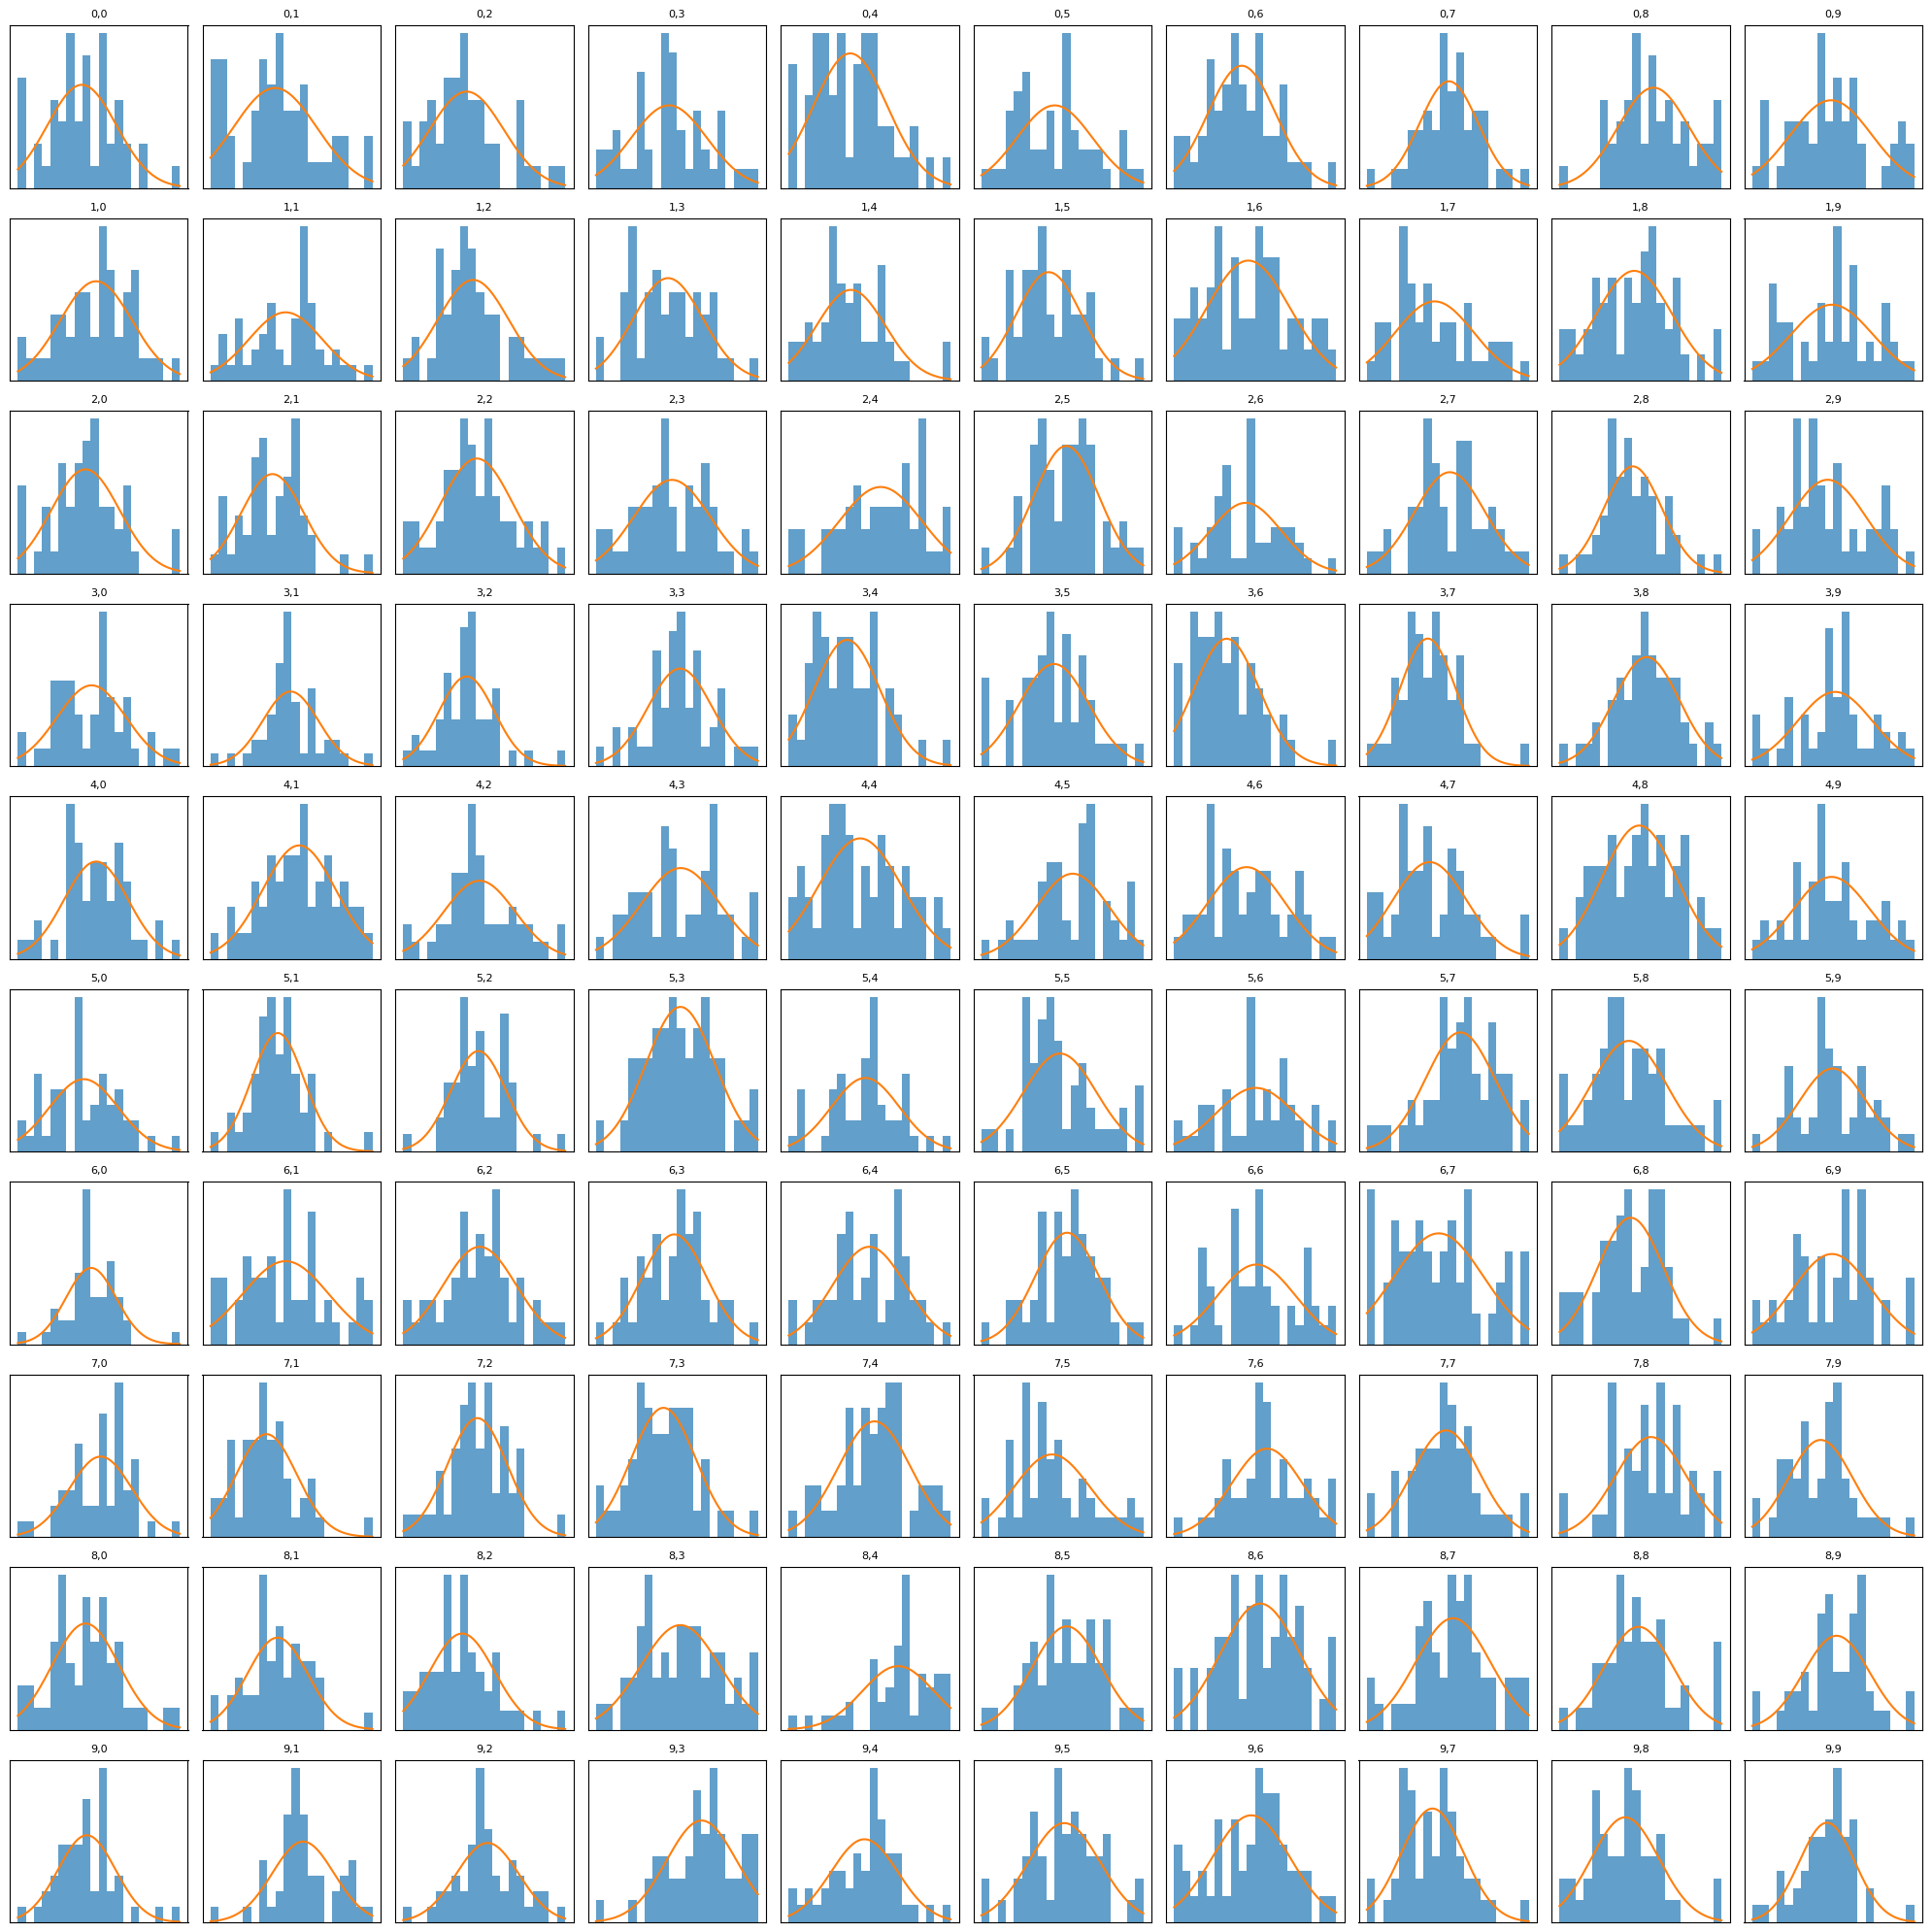

In [3]:
z=0

fig,axes=plt.subplots(10,10,figsize=(20,20))

for i in range(10):
    for j in range(10):

        x=all_ps[:,z,i,j]

        mu=np.mean(x)
        sigma=np.std(x)

        ax=axes[i,j]

        ax.hist(
            x,
            bins=20,
            density=True,
            alpha=0.7
        )

        xx=np.linspace(
            x.min(),
            x.max(),
            200
        )

        ax.plot(
            xx,
            norm.pdf(xx,mu,sigma)
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i},{j}",fontsize=8)

plt.tight_layout()
plt.show()

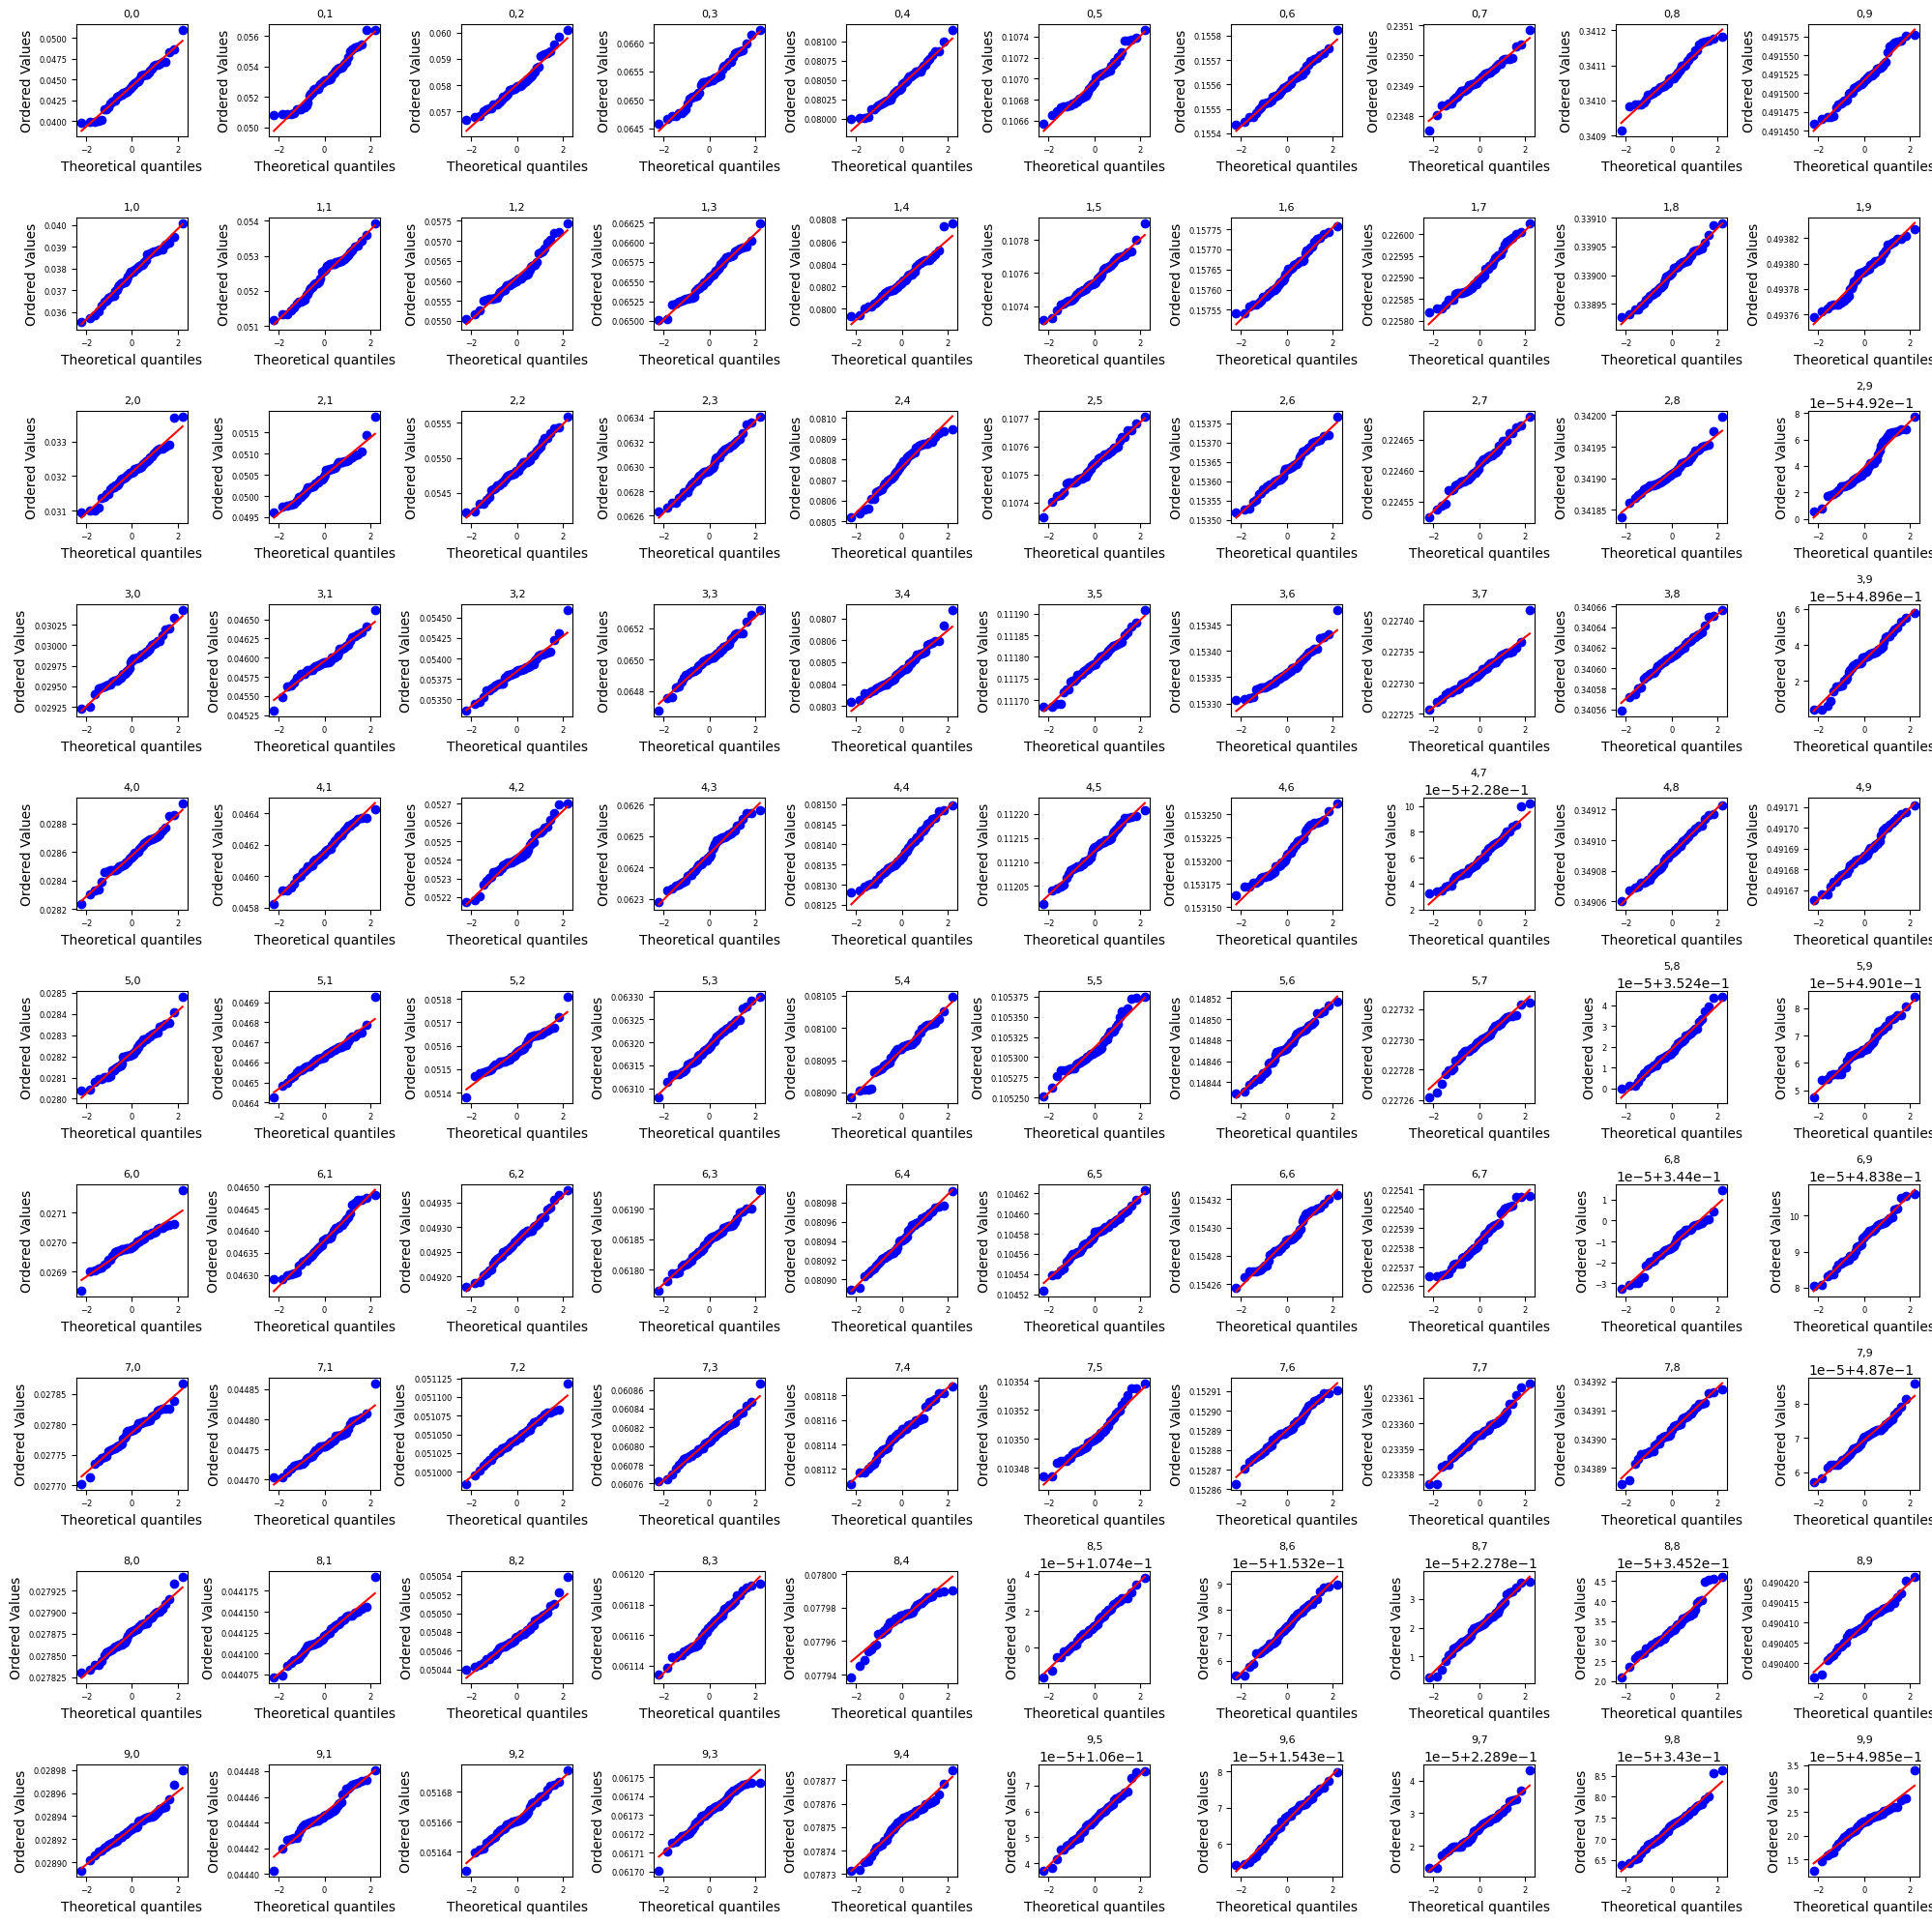

In [9]:
import scipy.stats as stats

z=0

fig,axes=plt.subplots(
    10,10,
    figsize=(20,20)
)

for i in range(10):
    for j in range(10):

        samples=all_ps[:,z,i,j]

        stats.probplot(
            samples,
            dist="norm",
            plot=axes[i,j]
        )

        axes[i,j].set_title(
            f"{i},{j}",
            fontsize=8
        )

        axes[i,j].tick_params(
            labelsize=6
        )

plt.tight_layout()
plt.show()

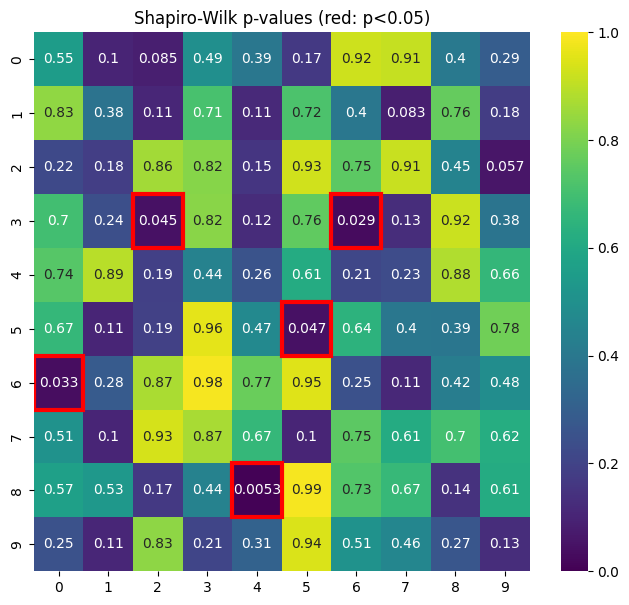

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from matplotlib.patches import Rectangle

pvals=np.zeros((10,10))

z=0

for i in range(10):
    for j in range(10):

        x=all_ps[:,z,i,j]

        stat,p=shapiro(x)

        pvals[i,j]=p


fig,ax=plt.subplots(figsize=(8,7))

sns.heatmap(
    pvals,
    annot=True,
    cmap="viridis",
    vmin=0,
    vmax=1,
    ax=ax
)

alpha=0.05

for i in range(10):
    for j in range(10):

        if pvals[i,j] < alpha:

            rect=Rectangle(
                (j,i),   
                1,
                1,
                fill=False,
                edgecolor='red',
                lw=3
            )

            ax.add_patch(rect)

plt.title(
    f"Shapiro-Wilk p-values (red: p<{alpha})"
)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_sigma_over_ps(all_ps, z_index=0, z_labels=None):
    """
    Plot a heatmap of sigma/mean_PS for a given redshift index.

    Parameters
    ----------
    all_ps : np.ndarray
        Shape (Nsims, Nz, Nx, Ny)
    z_index : int
        Redshift index to display
    z_labels : list of str, optional
        Labels for each redshift slice
    """
    ps_z = all_ps[:, z_index, :, :]       # (Nsims, Nx, Ny)
    mean_ps = ps_z.mean(axis=0)            # (Nx, Ny)
    std_ps  = ps_z.std(axis=0)            # (Nx, Ny)
    ratio   = std_ps / mean_ps            # (Nx, Ny)

    z_label = z_labels[z_index] if z_labels else f"z index {z_index}"

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        ratio,
        origin="lower",
        cmap="inferno",
        interpolation="nearest",
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\sigma / \langle PS \rangle$", fontsize=12)

    ax.set_title(rf"$\sigma / \langle PS \rangle$ at {z_label}", fontsize=13)
    ax.set_xlabel(r"$k_x$ index")
    ax.set_ylabel(r"$k_y$ index")

    stats = (
        f"min={ratio.min():.4f}  "
        f"max={ratio.max():.4f}  "
        f"mean={ratio.mean():.4f}"
    )
    ax.set_xlabel(rf"$k_x$ index    [{stats}]", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"sigma_over_ps_z{z_index}.png", dpi=150)
    plt.show()


# --- Usage ---
# all_ps shape: (Nsims, 3, 10, 10)
z_labels = ["z=0.5", "z=1.0", "z=2.0"]

plot_sigma_over_ps(all_ps, z_index=0, z_labels=z_labels)

Computing modes (vectorized)...


  Total modes: 5,359,375
  k_perp range: [0.0127, 2.2214] h/Mpc
  k_par  range: [0.0090,  1.5708] h/Mpc

k_edges: [0.050, 0.550] h/Mpc  (10 bins)
Filled bins: 100 / 100

Saved: ps2d_plot.png


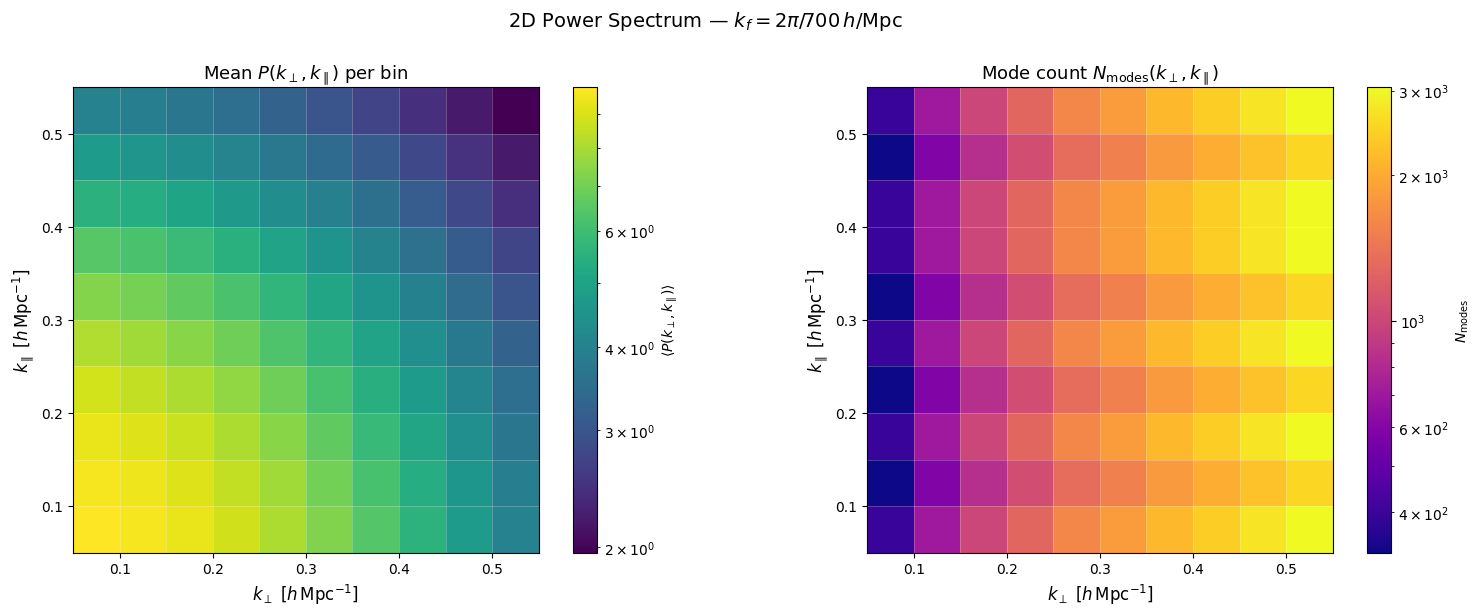

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker

def compute_simulated_data(box_len, hiidim):
    """
    Compute k_perp, k_par, and power for all Fourier modes.
    Vectorized with numpy meshgrid (no triple loop).
    """
    kf = 2 * np.pi / box_len

    # Build index arrays (i1, i2, i3) from 1 to hiidim//2
    idx = np.arange(1, hiidim // 2 + 1)
    i1, i2, i3 = np.meshgrid(idx, idx, idx, indexing='ij')

    kx = i1 * kf
    ky = i2 * kf
    kz = i3 * kf

    k_perp = np.sqrt(kx**2 + ky**2)  # perpendicular to line of sight
    k_par  = kz                        # parallel to line of sight

    k_mag = np.sqrt(k_perp**2 + k_par**2)

    # Toy power spectrum model (replace with your actual P(k))
    power = 1.0 / (k_mag**3 + 0.1)

    return k_perp.ravel(), k_par.ravel(), power.ravel()


# --- Parameters ---
box_len = 700.0  # Mpc/h
hiidim  = 350

kf = 2 * np.pi / box_len

# --- Generate modes ---
print("Computing modes (vectorized)...")
kperp_raw, kpar_raw, power_raw = compute_simulated_data(box_len, hiidim)
print(f"  Total modes: {len(kperp_raw):,}")
print(f"  k_perp range: [{kperp_raw.min():.4f}, {kperp_raw.max():.4f}] h/Mpc")
print(f"  k_par  range: [{kpar_raw.min():.4f},  {kpar_raw.max():.4f}] h/Mpc")

# --- BUG FIX 1: k_edges must start below the minimum k to capture all modes ---
# kf ~ 0.009, minimum k_perp ~ sqrt(2)*kf ~ 0.013 -> start well below that
k_edges = np.arange(0.05, 0.575, 0.05)
k_centers = (k_edges[:-1] + k_edges[1:]) / 2
print(f"\nk_edges: [{k_edges[0]:.3f}, {k_edges[-1]:.3f}] h/Mpc  ({len(k_edges)-1} bins)")

# --- BUG FIX 2: average the power correctly (power_sum / mode_count) ---
mode_count, _, _ = np.histogram2d(kperp_raw, kpar_raw, bins=[k_edges, k_edges])
power_sum,  _, _ = np.histogram2d(kperp_raw, kpar_raw, bins=[k_edges, k_edges],
                                   weights=power_raw)

with np.errstate(divide='ignore', invalid='ignore'):
    # Correct: mean power per bin, not mode_count
    power_2d = np.where(mode_count > 0, power_sum / mode_count, np.nan)

filled = np.count_nonzero(~np.isnan(power_2d))
print(f"Filled bins: {filled} / {power_2d.size}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left panel: 2D binned power spectrum ----
ax = axes[0]
X, Y = np.meshgrid(k_edges, k_edges)

valid = power_2d[~np.isnan(power_2d)]
f_min = valid.min() if len(valid) > 0 else 1e-10
f_max = valid.max() if len(valid) > 0 else 1.0

pcm = ax.pcolormesh(X, Y, power_2d.T,
                    norm=colors.LogNorm(vmin=f_min, vmax=f_max),
                    cmap='viridis', shading='flat')

# Bin grid lines
for edge in k_edges:
    ax.axhline(edge, color='white', linestyle='-', linewidth=0.4, alpha=0.4)
    ax.axvline(edge, color='white', linestyle='-', linewidth=0.4, alpha=0.4)

ax.set_xlabel(r'$k_{\perp}\ [h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax.set_ylabel(r'$k_{\parallel}\ [h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax.set_title(r'Mean $P(k_\perp, k_\parallel)$ per bin', fontsize=13)
ax.set_xlim(k_edges[0], k_edges[-1])
ax.set_ylim(k_edges[0], k_edges[-1])
ax.set_aspect('equal')

cbar = fig.colorbar(pcm, ax=ax, label=r'$\langle P(k_\perp, k_\parallel)\rangle$')

# ---- Right panel: mode count per bin ----
ax2 = axes[1]
pcm2 = ax2.pcolormesh(X, Y, mode_count.T,
                       norm=colors.LogNorm(vmin=max(1, mode_count[mode_count > 0].min()),
                                           vmax=mode_count.max()),
                       cmap='plasma', shading='flat')

for edge in k_edges:
    ax2.axhline(edge, color='white', linestyle='-', linewidth=0.4, alpha=0.4)
    ax2.axvline(edge, color='white', linestyle='-', linewidth=0.4, alpha=0.4)

ax2.set_xlabel(r'$k_{\perp}\ [h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel(r'$k_{\parallel}\ [h\,\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_title(r'Mode count $N_{\rm modes}(k_\perp, k_\parallel)$', fontsize=13)
ax2.set_xlim(k_edges[0], k_edges[-1])
ax2.set_ylim(k_edges[0], k_edges[-1])
ax2.set_aspect('equal')
fig.colorbar(pcm2, ax=ax2, label=r'$N_{\rm modes}$')

plt.suptitle(r'2D Power Spectrum — $k_f = 2\pi/700\,h/\mathrm{Mpc}$', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ps2d_plot.png', dpi=150, bbox_inches='tight')
print("\nSaved: ps2d_plot.png")
plt.show()

In [10]:
def compute_input_params(theta, seed = 1234,box_len=700, hiidim=350):
    user_params = p21c.SimulationOptions(
        BOX_LEN=box_len,
        HII_DIM=hiidim,
        DIM=hiidim*3,
        N_THREADS=16,
        SAMPLER_MIN_MASS= 1e10,
        DEXM_OPTIMIZE_MINMASS=3e11,
    )

    astro_options = p21c.AstroOptions(
        USE_TS_FLUCT=False,
        USE_X_RAY_HEATING=False,
        INHOMO_RECO=True,
        M_MIN_in_Mass=True
    )

    cosmo_params = p21c.CosmoParams(
        hlittle=0.6766,
        OMm=0.30964,
        OMb=0.04897,
        POWER_INDEX=0.9665,
        SIGMA_8=0.8102
    )
    astro_params = p21c.AstroParams(
        ALPHA_STAR=theta['ALPHA_STAR'], 
        F_STAR10=theta['F_STAR10'],
        F_ESC10=theta['F_ESC10'],
        ALPHA_ESC=theta['ALPHA_ESC'],
        M_TURN=theta['M_TURN'],
        t_STAR=theta['t_STAR'],
        L_X=theta['L_X'], #useless     
        NU_X_THRESH=theta['NU_X_THRESH'],  #useless  
        NU_X_BAND_MAX=2000.0, # Max of the band, don't moove this one ! 
    )
    inputs = p21c.InputParameters(
        cosmo_params=cosmo_params,
        astro_options=astro_options,
        astro_params=astro_params,
        simulation_options=user_params,
        random_seed=seed,
        node_redshifts=p21c.wrapper.inputs.get_logspaced_redshifts(
            min_redshift=6.00,
            z_step_factor=1.02,
            max_redshift=8.5,))

    return inputs

In [ ]:
theta_fixed = {
    'ALPHA_STAR': 0.5, 
    'F_STAR10': -1.3,
    'F_ESC10': -1,
    'ALPHA_ESC': -0.5,
    'M_TURN': 8.69, 
    't_STAR': 0.5,
    'L_X': 40.5,             
    'NU_X_THRESH': 500.0,     
    }
compute_input_params(theta_fixed)

NameError: name 'inputs' is not defined

PS1_PS2_Data/Pk_PS2_151.0_165.9.txt
[[0.13453745 0.08403152 0.06981407 0.05761362 0.05282131 0.04814161
  0.04514238 0.04163582 0.0406846  0.0374654 ]
 [0.13453745 0.08403152 0.06981407 0.05761362 0.05282131 0.04814159
  0.04514237 0.04163582 0.04068461 0.03746539]
 [0.13453745 0.08403151 0.06981407 0.0576136  0.05282131 0.04814159
  0.04514239 0.04163582 0.04068459 0.0374654 ]
 [0.13453744 0.0840315  0.06981407 0.05761361 0.05282131 0.04814162
  0.04514237 0.04163582 0.0406846  0.03746539]
 [0.13453744 0.08403151 0.06981407 0.05761362 0.05282131 0.0481416
  0.04514236 0.04163582 0.0406846  0.03746539]
 [0.13453745 0.08403152 0.06981407 0.05761361 0.05282132 0.0481416
  0.04514239 0.04163581 0.04068458 0.03746539]
 [0.13453743 0.0840315  0.06981406 0.0576136  0.05282131 0.04814162
  0.0451424  0.04163582 0.0406846  0.03746538]
 [0.13453744 0.08403149 0.06981407 0.0576136  0.05282131 0.0481416
  0.04514239 0.04163581 0.04068459 0.03746538]
 [0.13453746 0.0840315  0.06981407 0.05761362 0

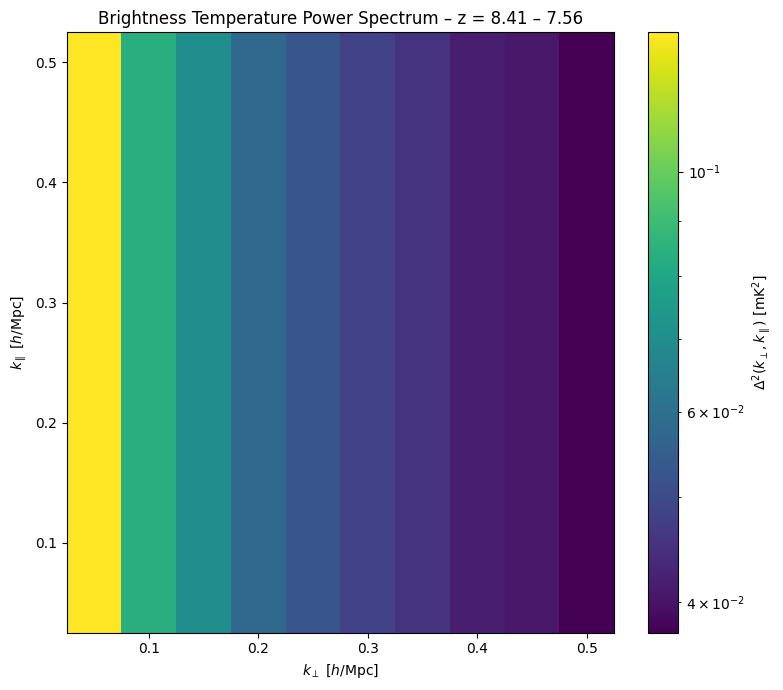

PS1_PS2_Data/Pk_PS2_166.0_180.9.txt
[[0.14224935 0.08543425 0.0697132  0.05938382 0.05381206 0.04983013
  0.04573441 0.04338277 0.04119765 0.0385075 ]
 [0.14224932 0.08543426 0.06971321 0.05938381 0.05381206 0.04983013
  0.04573441 0.04338276 0.04119763 0.03850749]
 [0.14224935 0.08543425 0.06971321 0.05938382 0.05381206 0.04983013
  0.04573441 0.04338276 0.04119764 0.0385075 ]
 [0.14224933 0.08543426 0.0697132  0.05938382 0.05381205 0.04983014
  0.0457344  0.04338277 0.04119764 0.0385075 ]
 [0.14224932 0.08543425 0.06971319 0.05938382 0.05381206 0.04983014
  0.04573441 0.04338275 0.04119765 0.03850752]
 [0.14224933 0.08543425 0.0697132  0.05938382 0.05381206 0.04983013
  0.04573438 0.04338276 0.04119765 0.0385075 ]
 [0.14224931 0.08543426 0.06971321 0.05938382 0.05381206 0.04983014
  0.04573439 0.04338275 0.04119764 0.03850752]
 [0.14224934 0.08543427 0.06971319 0.05938382 0.05381207 0.04983014
  0.0457344  0.04338276 0.04119765 0.03850751]
 [0.14224934 0.08543426 0.06971321 0.0593838

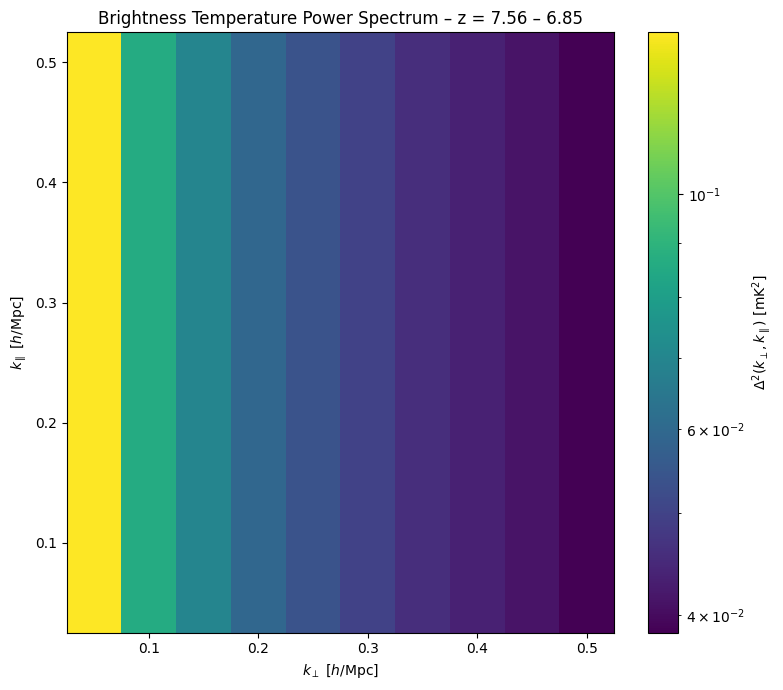

PS1_PS2_Data/Pk_PS2_181.0_195.9.txt
[[0.15587555 0.08505848 0.07273971 0.06155521 0.05536923 0.05051166
  0.04655276 0.0440155  0.0421649  0.0391247 ]
 [0.1558756  0.08505847 0.07273966 0.06155523 0.05536923 0.05051166
  0.04655276 0.04401552 0.0421649  0.03912469]
 [0.15587559 0.08505852 0.07273967 0.06155522 0.05536923 0.05051166
  0.04655276 0.04401552 0.0421649  0.0391247 ]
 [0.15587558 0.08505848 0.07273967 0.06155523 0.05536924 0.05051166
  0.04655277 0.04401552 0.0421649  0.0391247 ]
 [0.15587556 0.08505848 0.07273967 0.06155522 0.05536923 0.05051165
  0.04655277 0.0440155  0.0421649  0.0391247 ]
 [0.15587553 0.08505849 0.07273967 0.06155522 0.05536922 0.05051167
  0.04655276 0.04401552 0.04216491 0.03912471]
 [0.15587556 0.08505848 0.07273967 0.06155523 0.05536924 0.05051166
  0.04655277 0.04401552 0.04216488 0.0391247 ]
 [0.15587555 0.08505848 0.07273968 0.06155523 0.05536924 0.05051166
  0.04655277 0.04401551 0.0421649  0.03912469]
 [0.15587556 0.0850585  0.07273967 0.0615552

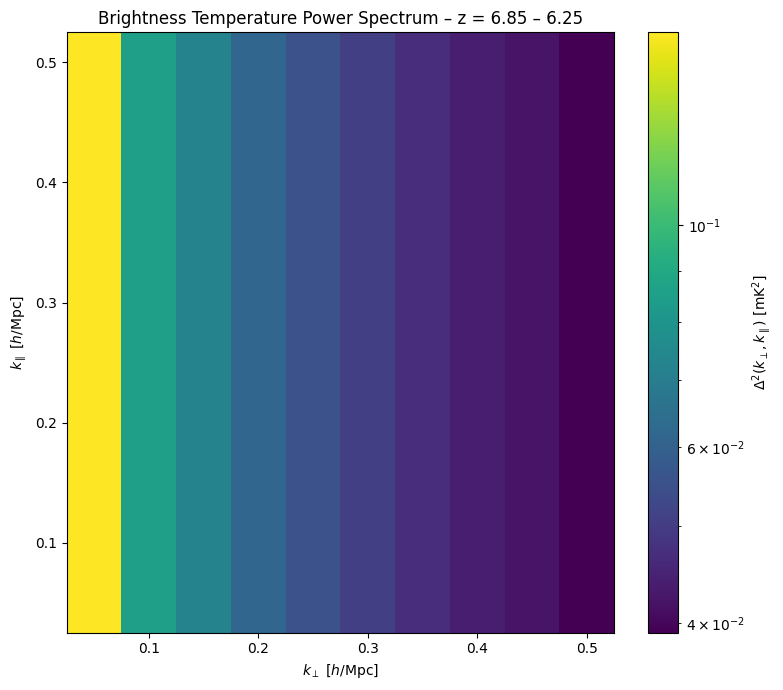

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm,Normalize

# Chargement des axes
kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/Pk_PS2_*.txt"))
z_ranges = [
    "z = 8.41 – 7.56",
    "z = 7.56 – 6.85",
    "z = 6.85 – 6.25"
]
for i,f in enumerate(files):
    data = np.loadtxt(f)
    print(f)
    data = ps2_true_err_list[i]/data  # Soustraction du bruit
    plt.figure(figsize=(8, 7))
    print(data)
    # pcolormesh avec shading='flat' ou 'nearest' affiche les données brutes
    # On définit les limites des axes pour correspondre aux vecteurs k  
    pcm = plt.pcolormesh(kperp, kpar, data, 
                         norm=LogNorm(vmin=data[data>0].min(), vmax=data[data>0].max()),
                         cmap='viridis')
    plt.colorbar(pcm, label=r'$\Delta^2(k_\perp, k_\parallel)$ [mK$^2$]')
    plt.xlabel(r'$k_\perp$ [$h$/Mpc]')
    plt.ylabel(r'$k_\parallel$ [$h$/Mpc]')
    plt.title(f'Brightness Temperature Power Spectrum – {z_ranges[i]}')    
    plt.tight_layout()
    plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/err_Pk_PS2_*.txt"))
files_noise = sorted(glob.glob("PS1_PS2_Data/Pk_PS_averaged_noise_*.txt"))

z_ranges = [
    "7.96",
    "7.19",
    "6.54"
]
ps2_true_err_list = []
ps2_average_noise_list = []
for i, f in enumerate(files):
    data_std = np.loadtxt(f)
    data_average_noise = np.loadtxt(files_noise[i])
    ps2_true_err_list.append(data_std)
    ps2_average_noise_list.append(data_average_noise)

In [2]:
import torch

ckpt = torch.load("emulator/checkpoints/emulator.pt", map_location="cpu")
print(type(ckpt))
print(ckpt.keys() if isinstance(ckpt, dict) else "→ pas un dict, c'est le modèle directement")

<class 'collections.OrderedDict'>
odict_keys(['shared.0.weight', 'shared.0.bias', 'shared.1.weight', 'shared.1.bias', 'shared.3.weight', 'shared.3.bias', 'shared.4.weight', 'shared.4.bias', 'shared.6.weight', 'shared.6.bias', 'shared.7.weight', 'shared.7.bias', 'ps2d_fc.0.weight', 'ps2d_fc.0.bias', 'ps2d_fc.2.weight', 'ps2d_fc.2.bias', 'ps2d_cnn.0.weight', 'ps2d_cnn.0.bias', 'ps2d_cnn.2.weight', 'ps2d_cnn.2.bias', 'ps2d_cnn.4.weight', 'ps2d_cnn.4.bias', 'xhi_head.0.weight', 'xhi_head.0.bias', 'xhi_head.2.weight', 'xhi_head.2.bias', 'xhi_head.4.weight', 'xhi_head.4.bias'])


In [3]:
from emulator.model import Emulator21cm

model = Emulator21cm(n_params=6, n_redshifts=3)

model.load_state_dict(ckpt)  # ckpt est déjà le state_dict
model.eval()  # mode évaluation

Emulator21cm(
  (shared): Sequential(
    (0): Linear(in_features=6, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
  )
  (ps2d_fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=1200, bias=True)
  )
  (ps2d_cnn): Sequential(
    (0): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(16,

In [4]:
theta = [0.5, -1.5, -1, -0.5, 8.69, 0.5]  # ALPHA_STAR, F_STAR10, F_ESC10, ALPHA_ESC, M_TURN, t_STAR
t = torch.tensor(theta, dtype=torch.float32).unsqueeze(0)


In [5]:
with torch.no_grad():
    ps2d, xhi = model(t)

print(ps2d.shape)   # → (1, 3, 10, 10)
print(xhi.shape)    # → (1, 3)
print(xhi)          # → fraction neutre aux 3 redshifts, ∈ [0, 1]
ps2d = ps2d.squeeze(0).numpy().flatten()
print(ps2d.shape)   # → (300,)
xhi = xhi.squeeze(0).numpy()
print(xhi.shape)    # → (3,)

torch.Size([1, 3, 10, 10])
torch.Size([1, 3])
tensor([[0.2656, 0.3760, 0.4980]])
(300,)
(3,)


In [6]:
import numpy as np

In [7]:
PARAM_NAMES  = ['ALPHA_STAR', 'F_STAR10', 'F_ESC10', 'ALPHA_ESC', 'M_TURN', 't_STAR']
PRIOR_BOUNDS = np.array([
    (-0.5,  1.0),   # ALPHA_STAR
    (-3.0,  0.0),   # F_STAR10
    (-3.0,  1.0),   # F_ESC10
    (-1.0,  0.5),   # ALPHA_ESC
    ( 8.0, 10.0),   # M_TURN
    ( 0.0,  1.0),   # t_STAR
])

In [8]:
def run_emulator(model, theta: np.ndarray, device: str):
    """
    Args:
        theta : (6,) array in physical units
    Returns:
        ps2d_flat : (300,) flattened  [3 redshifts × 10 × 10]
        xhi       : (3,)  neutral fractions
    """
    t = torch.tensor(theta, dtype=torch.float32, device=device).unsqueeze(0)
 
    with torch.no_grad():
        ps2d, xhi = model(t)
 
    ps2d_flat = ps2d.squeeze(0).cpu().numpy().flatten()   # (300,)
    xhi_out   = xhi.squeeze(0).cpu().numpy()              # (3,)
    return ps2d_flat, xhi_out

In [9]:
def log_prior(theta: np.ndarray) -> float:
    lo, hi = PRIOR_BOUNDS[:, 0], PRIOR_BOUNDS[:, 1]
    return 0.0 if np.all(theta >= lo) and np.all(theta <= hi) else -np.inf
 
 
def log_likelihood(y_obs: np.ndarray, y_pred: np.ndarray, sigma: np.ndarray) -> float:
    return -0.5 * float(np.sum(((y_obs - y_pred) / sigma) ** 2))

In [14]:
def run_mcmc(
    model,
    y_obs:        np.ndarray,
    sigma:        np.ndarray,
    device:       str   = "cpu",
    n_steps:      int   = 10_000,
    burn_in:      int   = 2_000,
    proposal_std: float = 0.05,     # fraction of prior width per step
    theta_init:   np.ndarray = None,
    seed:         int   = 42,
) -> dict:
    """
    Metropolis-Hastings MCMC.
 
    Returns a dict with keys:
        chain          : (n_steps, 6)          full chain
        posterior      : (n_steps-burn_in, 6)  post burn-in parameters
        xhi_posterior  : (n_steps-burn_in, 3)  post burn-in neutral fractions
        log_post       : (n_steps-burn_in,)    log-posterior values
        accept_rate    : float
    """
    rng    = np.random.default_rng(seed)
    widths = PRIOR_BOUNDS[:, 1] - PRIOR_BOUNDS[:, 0]
 
    # Starting point: prior centre if not provided
    if theta_init is None:
        theta_init = 0.5 * (PRIOR_BOUNDS[:, 0] + PRIOR_BOUNDS[:, 1])
 
    # Storage
    chain     = np.zeros((n_steps, len(PARAM_NAMES)))
    xhi_chain = np.zeros((n_steps, 3))
    lp_chain  = np.zeros(n_steps)
 
    # Evaluate initial point
    theta_cur = theta_init.copy()
    ps2d_cur, xhi_cur = run_emulator(model, theta_cur, device)
    lp_cur = log_prior(theta_cur) + log_likelihood(y_obs, ps2d_cur, sigma)
 
    n_accept = 0
 
    for i in range(n_steps):
 
        # ── Propose ────────────────────────────────────────────────────────
        theta_prop = theta_cur + proposal_std * widths * rng.standard_normal(len(PARAM_NAMES))
 
        # ── Evaluate ────────────────────────────────────────────────────────
        lp_prior_prop = log_prior(theta_prop)
        if np.isfinite(lp_prior_prop):
            ps2d_prop, xhi_prop = run_emulator(model, theta_prop, device)
            lp_prop = lp_prior_prop + log_likelihood(y_obs, ps2d_prop, sigma)
        else:
            lp_prop = -np.inf
 
        # ── Accept / Reject ─────────────────────────────────────────────────
        if np.log(rng.uniform()) < (lp_prop - lp_cur):
            theta_cur, xhi_cur, lp_cur = theta_prop, xhi_prop, lp_prop
            n_accept += 1
 
        chain[i]     = theta_cur
        xhi_chain[i] = xhi_cur
        lp_chain[i]  = lp_cur
 
        # ── Progress ────────────────────────────────────────────────────────
        if (i + 1) % 500 == 0:
            print(f"  step {i+1:>6}/{n_steps}  |  "
                  f"accept rate: {n_accept/(i+1):.2%}  |  "
                  f"log-post: {lp_cur:.2f}")
 
    return {
        "chain":         chain,
        "posterior":     chain[burn_in:],
        "xhi_posterior": xhi_chain[burn_in:],
        "log_post":      lp_chain[burn_in:],
        "accept_rate":   n_accept / n_steps,
    }

In [16]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


In [17]:
print(sigma)

[0.00709416 0.00590922 0.00496553 0.00411504 0.00480539 0.00553368
 0.00782019 0.00974371 0.01381972 0.0180957  0.00686686 0.00550113
 0.00456109 0.0040436  0.00469381 0.0052541  0.00672054 0.00974832
 0.014133   0.01726451 0.00590728 0.00491154 0.00419414 0.00432162
 0.00484313 0.00503603 0.00722908 0.00903567 0.01481137 0.01774972
 0.00498661 0.00491103 0.00416444 0.00397661 0.00467851 0.00555948
 0.00703213 0.00919382 0.01480788 0.01793791 0.00580499 0.00470368
 0.00460289 0.00374365 0.00480704 0.00538156 0.00686451 0.00993554
 0.01394101 0.01868183 0.00551654 0.00501363 0.00426901 0.00407641
 0.00482667 0.00499629 0.00715891 0.00964666 0.01362641 0.01756845
 0.00463932 0.00448629 0.00406832 0.00379446 0.00439706 0.0055855
 0.00680332 0.0092086  0.01409036 0.01750705 0.00422045 0.00352119
 0.00384109 0.0042071  0.0045201  0.00498958 0.00728407 0.00899313
 0.01366544 0.0169001  0.00403749 0.00382399 0.00392179 0.00393746
 0.00461757 0.00546301 0.00681079 0.00949071 0.01433984 0.01807

In [18]:
import glob

In [24]:
point_number = "0002"
y_obs = np.load(f"low_generate_data/results/point_{point_number}/ps2d.npy", allow_pickle = True) 
theta_obs = np.load(f"low_generate_data/results/point_{point_number}/theta.npy", allow_pickle = True)
xHI_obs = np.load(f"low_generate_data/results/point_{point_number}/xHI.npy", allow_pickle = True)  

AttributeError: 'numpy.ndarray' object has no attribute 'value'

: 

In [27]:
y_obs.shape, theta_obs.shape, xHI_obs.shape

((300,), (), (3,))

In [25]:
y_obs  = np.array(y_obs).flatten()
xHI_obs = np.array(xHI_obs).flatten()
sigma  = np.concatenate([np.loadtxt(f).flatten()
                             for f in sorted(glob.glob("PS1_PS2_Data/err_Pk_PS2_*.txt"))])

In [28]:
results = run_mcmc(
        model        = model,
        y_obs        = y_obs,
        sigma        = sigma,
        device       = DEVICE,
        n_steps      = 10_000,
        burn_in      = 2_000,
        proposal_std = 0.005,
    )

  step    500/10000  |  accept rate: 40.20%  |  log-post: -519.54
  step   1000/10000  |  accept rate: 41.30%  |  log-post: -513.58
  step   1500/10000  |  accept rate: 42.13%  |  log-post: -514.92
  step   2000/10000  |  accept rate: 41.95%  |  log-post: -514.83
  step   2500/10000  |  accept rate: 42.04%  |  log-post: -512.69
  step   3000/10000  |  accept rate: 42.03%  |  log-post: -513.14
  step   3500/10000  |  accept rate: 42.86%  |  log-post: -512.52
  step   4000/10000  |  accept rate: 42.55%  |  log-post: -514.54
  step   4500/10000  |  accept rate: 42.24%  |  log-post: -515.17
  step   5000/10000  |  accept rate: 42.24%  |  log-post: -516.39
  step   5500/10000  |  accept rate: 42.16%  |  log-post: -513.53
  step   6000/10000  |  accept rate: 41.88%  |  log-post: -515.76
  step   6500/10000  |  accept rate: 41.80%  |  log-post: -516.50
  step   7000/10000  |  accept rate: 41.83%  |  log-post: -516.05
  step   7500/10000  |  accept rate: 42.16%  |  log-post: -517.41
  step   8

In [1]:
run_emulator(model, np.array(list(theta_obs.values())), DEVICE)

NameError: name 'run_emulator' is not defined

In [19]:
from scipy.optimize import minimize
import numpy as np

def neg_log_likelihood(theta):
    # Retourne +inf si hors prior
    lo, hi = PRIOR_BOUNDS[:, 0], PRIOR_BOUNDS[:, 1]
    if not (np.all(theta >= lo) and np.all(theta <= hi)):
        return np.inf
    ps2d_t, _ = run_emulator(model, theta, device="cpu")
    return 0.5 * np.sum(((y_obs - ps2d_t) / sigma)**2)

# Lance depuis plusieurs points de départ
best_result = None
for _ in range(20):
    theta0 = np.array([
        np.random.uniform(lo, hi) for lo, hi in PRIOR_BOUNDS
    ])
    res = minimize(neg_log_likelihood, theta0, method="Nelder-Mead",
                   options={"maxiter": 10_000, "xatol": 1e-4, "fatol": 1e-4})
    if best_result is None or res.fun < best_result.fun:
        best_result = res

print(f"Best log-L found : {-best_result.fun:.2f}")
print("Best theta:")
for name, val in zip(PARAM_NAMES, best_result.x):
    print(f"  {name:<14}: {val:.4f}")

Best log-L found : -5.56
Best theta:
  ALPHA_STAR    : 0.0154
  F_STAR10      : -1.3341
  F_ESC10       : -0.2087
  ALPHA_ESC     : -0.6549
  M_TURN        : 9.5044
  t_STAR        : 0.0051


In [ ]:
theta_obs

array({'ALPHA_STAR': np.float64(0.27037661196663976), 'F_STAR10': np.float64(-1.4132807543501258), 'F_ESC10': np.float64(-0.21544912084937096), 'ALPHA_ESC': np.float64(-0.4071343974210322), 'M_TURN': np.float64(9.315577005967498), 't_STAR': np.float64(0.01980763114988804)},
      dtype=object)

: 

In [ ]:
import numpy as np

kpar_challenge = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kper_challenge = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

# Your bin centers
k_edges = np.arange(0.025, 0.575, 0.05)
k_centers = 0.5 * (k_edges[:-1] + k_edges[1:])

print("Challenge kpar:", kpar_challenge)
print("Your k centers:", k_centers)
print("Match:", np.allclose(kpar_challenge, k_centers, atol=1e-3))

In [4]:
ps2_true_err_list

[array([[0.00709416, 0.00590922, 0.00496553, 0.00411504, 0.00480539,
         0.00553368, 0.00782019, 0.00974371, 0.01381972, 0.0180957 ],
        [0.00686686, 0.00550113, 0.00456109, 0.0040436 , 0.00469381,
         0.0052541 , 0.00672054, 0.00974832, 0.014133  , 0.01726451],
        [0.00590728, 0.00491154, 0.00419414, 0.00432162, 0.00484313,
         0.00503603, 0.00722908, 0.00903567, 0.01481137, 0.01774972],
        [0.00498661, 0.00491103, 0.00416444, 0.00397661, 0.00467851,
         0.00555948, 0.00703213, 0.00919382, 0.01480788, 0.01793791],
        [0.00580499, 0.00470368, 0.00460289, 0.00374365, 0.00480704,
         0.00538156, 0.00686451, 0.00993554, 0.01394101, 0.01868183],
        [0.00551654, 0.00501363, 0.00426901, 0.00407641, 0.00482667,
         0.00499629, 0.00715891, 0.00964666, 0.01362641, 0.01756845],
        [0.00463932, 0.00448629, 0.00406832, 0.00379446, 0.00439706,
         0.0055855 , 0.00680332, 0.0092086 , 0.01409036, 0.01750705],
        [0.00422045, 0.0035

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

# Chemin vers vos résultats
output_dir = "results_simu"
files = sorted(glob.glob(f"../{output_dir}/data_z_*.npz"))
ps2d_list = []
print("ok")
for i,f in enumerate(files):
    # 1. Charger le fichier .npz
    container = np.load(f)
    
    # 2. Extraire les données en utilisant les clés définies lors du np.savez
    ps2d = container['ps2d']
    kperp = container['kperp']
    kpar = container['kpar']
    
    # Extraire le redshift du nom du fichier pour le titre
    # (ou vous pouvez l'ajouter dans le np.savez lors de la simulation)
    z_str = f.split('_z_')[-1].replace('.npz', '')

    plt.figure(figsize=(8, 7))
    
    # 3. Affichage
    # Note : pcolormesh prend souvent les bords des bins. 
    # Si kperp et kpar sont les centres, le rendu sera correct avec shading='auto'
    fonction = ps2_true_err_list[i]
    ps2d_list.append(fonction)
    pcm = plt.pcolormesh(kperp, kpar, fonction, 
                         norm=LogNorm(vmin=fonction[fonction > 0].min(), vmax=fonction.max()),
                         cmap='viridis',
                         shading='auto')
    
    plt.colorbar(pcm, label=r'$P(k_\perp, k_\parallel)$ [mK$^2 \cdot h^{-3} \text{Mpc}^3$]')
    plt.xlabel(r'$k_\perp$ [$h$/Mpc]')
    plt.ylabel(r'$k_\parallel$ [$h$/Mpc]')
    plt.title(f'2D Power Spectrum – z = {z_str}')
    plt.tight_layout()
    plt.show()

ok


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import LogNorm

kpar = np.loadtxt("PS1_PS2_Data/bins_kpar.txt")
kperp = np.loadtxt("PS1_PS2_Data/bins_kper.txt")

files = sorted(glob.glob("PS1_PS2_Data/Pk_PS2_*.txt"))

z_ranges = [
    "7.96",
    "7.19",
    "6.54"
]
ps2_true_list = []
z_ranges_list = []
for i, f in enumerate(files):

    data = np.loadtxt(f)
    ps2_true_list.append(data)
    z_ranges_list.append(z_ranges[i])

FileNotFoundError: PS1_PS2_Data/bins_kpar.txt not found.

In [5]:
ps2d_pred = np.array(ps2d_list).flatten()
ps2_true = np.array(ps2_true_list).flatten()
ps2_std = (np.array(ps2_true_err_list)).flatten()

In [8]:
def compute_sigma():
    return ps2_std

def log_likelihood(y_true, y_pred):
    sigma = compute_sigma()
    chi_square_vec = y_true - y_pred
    norm = 1.0 / np.sqrt((2 * np.pi) ** len(sigma) * np.prod(sigma ** 2))
    exponent = -0.5 * np.sum((chi_square_vec / sigma) ** 2)
    return exponent   

In [9]:
log_likelihood(ps2_true, ps2d_pred)

/tmp/ipykernel_890431/2760000367.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  norm = 1.0 / np.sqrt((2 * np.pi) ** len(sigma) * np.prod(sigma ** 2))


np.float64(-8187.246547041153)